In [2]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd

# 1. Download the drivable street network of Barcelona
G = ox.graph_from_place("Barcelona, Spain", network_type="drive")

# 2. Convert graph to GeoDataFrames (nodes = intersections, edges = roads)
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

# 3. Compute centrality metrics
# Betweenness (flow concentration)
bet_centrality = nx.betweenness_centrality(G, weight='length', normalized=True)

# Closeness (accessibility)
#close_centrality = nx.closeness_centrality(G, distance='length')

# Degree (local connectivity)
#degree_centrality = dict(G.degree())

# Eigenvector (influence within network)
#eig_centrality = nx.eigenvector_centrality_numpy(G, weight='length')

# 4. Attach metrics to node GeoDataFrame
gdf_nodes["betweenness"] = gdf_nodes.index.map(bet_centrality)
#gdf_nodes["closeness"] = gdf_nodes.index.map(close_centrality)
#gdf_nodes["degree"] = gdf_nodes.index.map(degree_centrality)
#gdf_nodes["eigenvector"] = gdf_nodes.index.map(eig_centrality)

# 5. Basic summary
summary = gdf_nodes[["betweenness"]].describe()
print(summary)

# 6. (Optional) Spatial export for further analysis or visualization
gdf_nodes.to_file("barcelona_network_metrics.geojson", driver="GeoJSON")


       betweenness
count  8887.000000
mean      0.006804
std       0.009747
min       0.000000
25%       0.000703
50%       0.002737
75%       0.008625
max       0.096446


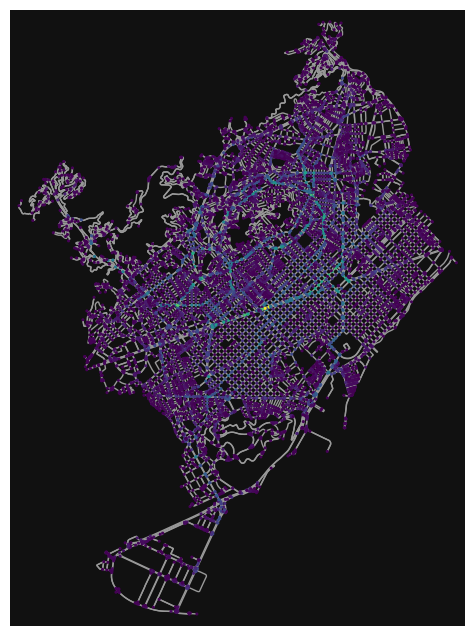

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [9]:
ox.plot_graph(G, node_color=gdf_nodes["betweenness"], node_size=5)

In [12]:
import folium

# Convert to WGS84 (lat/lon) for web mapping
gdf_nodes_latlon = gdf_nodes.to_crs(epsg=4326)

# Create a Folium map centered on Barcelona
m = folium.Map(location=[41.3851, 2.1734], zoom_start=12, tiles="cartodbpositron")

# Normalize betweenness for better color scaling
bet_norm = (gdf_nodes_latlon["betweenness"] - gdf_nodes_latlon["betweenness"].min()) / (
    gdf_nodes_latlon["betweenness"].max() - gdf_nodes_latlon["betweenness"].min()
)

# Add nodes as circles proportional to betweenness
for _, row in gdf_nodes_latlon.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=2 + 6 * bet_norm.loc[row.name],
        color="red",
        fill=True,
        fill_opacity=0.6,
        weight=0,
    ).add_to(m)

# Add layer control and display map
folium.LayerControl().add_to(m)
# m.save("barcelona_network_betweenness.html")
m

In [58]:
import osmnx as ox
G = ox.graph_from_place("Barcelona, Spain", network_type="drive")

gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)
gdf_edges.head()


osmid  \
u        v           key                                                      
21638845 885308258   0                                            554707785   
         13175411896 0    [1433594636, 4079500, 543357596, 902517725, 42...   
21638865 30343650    0                                              4079505   
21638867 1636238503  0                                              4079509   
         1403082237  0                                              4079509   

                          oneway   lanes                      name  \
u        v           key                                             
21638845 885308258   0      True       2  Passeig de Joan de Borbó   
         13175411896 0     False  [3, 4]  Passeig de Joan de Borbó   
21638865 30343650    0      True     NaN         Carrer del Judici   
21638867 1636238503  0     False       2   Carrer de Pepe Rubianes   
         1403082237  0     False       2   Carrer de Pepe Rubianes   

                                highway maxspeed reversed   length  \
u        v           key                                             
21638845 885308258   0      residential       30    False   28.335   
         13175411896 0      residential       30     True  616.484   
21638865 30343650    0    living_street       20    False   15.466   
21638867 1636238503  0         tertiary       30     True   15.734   
         1403082237  0         tertiary       30    False   15.417   

                                                                   geometry  \
u        v           key                                                      
21638845 885308258   0      LINESTRING (2.18774 41.37009, 2.18771 41.36984)   
         13175411896 0    LINESTRING (2.18774 41.37009, 2.18769 41.37017...   
21638865 30343650    0    LINESTRING (2.19063 41.37677, 2.19048 41.37674...   
21638867 1636238503  0      LINESTRING (2.18893 41.37821, 2.18875 41.37817)   
         1403082237  0    LINESTRING (2.18893 41.37821, 2.189 41.37822, ...   

                         access junction  ref width est_width tunnel bridge  \
u        v           key                                                      
21638845 885308258   0      NaN      NaN  NaN   NaN       NaN    NaN    NaN   
         13175411896 0      NaN      NaN  NaN   NaN       NaN    NaN    NaN   
21638865 30343650    0      NaN      NaN  NaN   NaN       NaN    NaN    NaN   
21638867 1636238503  0      NaN      NaN  NaN   NaN       NaN    NaN    NaN   
         1403082237  0      NaN      NaN  NaN   NaN       NaN    NaN    NaN   

                         service  
u        v           key          
21638845 885308258   0       NaN  
         13175411896 0       NaN  
21638865 30343650    0       NaN  
21638867 1636238503  0       NaN  
         1403082237  0       NaN

In [56]:
gdf_edges["highway"].value_counts()

highway
residential                               8172
tertiary                                  2647
living_street                             2056
secondary                                 1505
primary                                    580
[living_street, residential]               391
tertiary_link                              259
primary_link                               240
secondary_link                             176
unclassified                               141
trunk_link                                 139
trunk                                      104
busway                                      10
[tertiary, residential]                      9
[residential, unclassified]                  6
motorway_link                                5
[residential, secondary]                     4
[tertiary, living_street]                    4
[trunk, primary]                             4
[residential, tertiary_link]                 3
[residential, trunk_link]                    3
[prim